# Cassava Leaf Disease Classification — MobileNetV2
 

## 0. Install Dependencies

In [ ]:
%pip install tensorflow scikit-learn matplotlib seaborn -q

## 1. Imports & Reproducibility

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # scales to [-1,1]
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, Callback
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.19.0
GPU available: False


## 2. Custom Callbacks

In [3]:
class StopAt92(Callback):
    """Stop training once val_accuracy hits 92%."""
    def on_epoch_end(self, epoch, logs=None):
        if logs.get("val_accuracy", 0) >= 0.92:
            print(f"\n  ✅ Reached 92% val_accuracy at epoch {epoch + 1}. Stopping.")
            self.model.stop_training = True

class StopAtTrainAcc(Callback):
    """Stop when training accuracy hits target (from friends' script)."""
    def __init__(self, target=0.94):
        super().__init__()
        self.target = target
    def on_epoch_end(self, epoch, logs=None):
        if logs.get("accuracy", 0) >= self.target:
            print(f"\n  ✅ Train accuracy {self.target*100:.0f}% reached at epoch {epoch+1}. Stopping.")
            self.model.stop_training = True

## 3. Config — Update Paths Here

In [4]:
DATA_DIR    = r'C:\Users\Alfred\Desktop\data'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4
SEED        = 42
MODEL_SAVE  = "cassava_mobilenetv2_final.h5"
LOG_CSV     = "cassava_mobilenetv2_log.csv"
PLOT_FILE   = "training_history_mobilenet.png"

In [5]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ── 1. Load all images from DATA_DIR ──────────────────────────────────────────
DATA_DIR = r'C:\Users\Alfred\Desktop\data'

data_list = []
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            data_list.append({
                'image_path': os.path.join(class_path, img_file),
                'label': class_name
            })

df = pd.DataFrame(data_list)

# ── 2. Dataset overview ───────────────────────────────────────────────────────
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print("\nClass distribution:")
counts = df['label'].value_counts()
for cls, count in counts.items():
    bar = '█' * (count // 50)
    print(f"  {cls:<45} {count:>5}  {bar}")

# ── 3. Train / Val split (80% train, 20% val, stratified) ────────────────────
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

print(f"\nSplit summary:")
print(f"  Train : {len(train_df)} images")
print(f"  Val   : {len(val_df)} images")
print(f"\nTrain class distribution:")
print(train_df['label'].value_counts().to_string())
print(f"\nVal class distribution:")
print(val_df['label'].value_counts().to_string())

Total images: 9726
Number of classes: 4

Class distribution:
  Cassava___brown_streak_disease                 2448  ████████████████████████████████████████████████
  Cassava___mosaic_disease                       2448  ████████████████████████████████████████████████
  Cassava___healthy                              2444  ████████████████████████████████████████████████
  Cassava___green_mottle                         2386  ███████████████████████████████████████████████

Split summary:
  Train : 7780 images
  Val   : 1946 images

Train class distribution:
label
Cassava___mosaic_disease          1958
Cassava___brown_streak_disease    1958
Cassava___healthy                 1955
Cassava___green_mottle            1909

Val class distribution:
label
Cassava___mosaic_disease          490
Cassava___brown_streak_disease    490
Cassava___healthy                 489
Cassava___green_mottle            477


## 4. Data Generators
> `preprocess_input` from `mobilenet_v2` scales pixels to `[-1, 1]`. Kept from friends' script — this is correct and essential.

In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Classes : {train_data.class_indices}")
print(f"Train   : {train_data.samples} images")
print(f"Val     : {val_data.samples} images")

Found 7780 validated image filenames belonging to 4 classes.
Found 1946 validated image filenames belonging to 4 classes.
Classes : {'Cassava___brown_streak_disease': 0, 'Cassava___green_mottle': 1, 'Cassava___healthy': 2, 'Cassava___mosaic_disease': 3}
Train   : 7780 images
Val     : 1946 images


## 5. Class Weights (dynamic — from friends' MobileNet script)

In [8]:
total         = train_data.samples
class_counts  = np.bincount(train_data.classes)
class_weights = {i: total / (NUM_CLASSES * c) for i, c in enumerate(class_counts)}
print("Class weights:", {k: round(v, 4) for k, v in class_weights.items()})

Class weights: {0: np.float64(0.9934), 1: np.float64(1.0189), 2: np.float64(0.9949), 3: np.float64(0.9934)}


## 6. Build Model
> Head upgraded: added `BatchNormalization` + second `Dense` layer compared to friends' script, for better 4-class discrimination.

In [9]:
tf.keras.backend.clear_session()

base = MobileNetV2(input_shape=(224, 224, 3), alpha=1.0,
                   include_top=False, weights="imagenet")
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = models.Model(inputs=base.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Total params    : {model.count_params():,}")
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Trainable params: {trainable_params:,}")


Total params    : 2,624,452
Trainable params: 363,908


## 7. Phase 1 — Train Head Only (base frozen, 20 epochs)

In [10]:
callbacks_p1 = [
    StopAt92(),
    StopAtTrainAcc(target=0.94),
    ModelCheckpoint("cassava_mobilenet_best_phase1.keras", save_best_only=True,
                    monitor="val_accuracy", verbose=1),
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    CSVLogger(LOG_CSV)
]

print("[Phase 1] Training classification head — base frozen")
history_p1 = model.fit(
    train_data, validation_data=val_data,
    epochs=20, class_weight=class_weights,
    callbacks=callbacks_p1, verbose=1
)

print(f"\n✓ Phase 1 best val_accuracy: {max(history_p1.history['val_accuracy']):.4f}")

[Phase 1] Training classification head — base frozen


c:\Users\Alfred\.conda\envs\pig_disease_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4259 - loss: 1.4843
Epoch 1: val_accuracy improved from -inf to 0.60534, saving model to cassava_mobilenet_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.4261 - loss: 1.4836 - val_accuracy: 0.6053 - val_loss: 1.0426 - learning_rate: 0.0010
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5525 - loss: 1.1163
Epoch 2: val_accuracy did not improve from 0.60534
244/244 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.5525 - loss: 1.1163 - val_accuracy: 0.5766 - val_loss: 1.0550 - learning_rate: 0.0010
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5778 - loss: 1.0564
Epoch 3: val_accuracy improved from 0.60534 to 0.63155, saving model to cassava_mobilenet_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.5778 - loss: 1.0564 - val_accuracy: 0.6316 - val_loss: 0.9652 - learning_rate: 0.0010
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - ac

## 8. Phase 2 — Fine-tune Last 30 Layers
> Kept from friends' script: unfreeze last 30 layers specifically (not a percentage). Works well for MobileNetV2's architecture.

In [11]:
base.trainable = True
for layer in base.layers[:-50]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in base.layers if l.trainable)}")

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p2 = [
    StopAt92(),
    StopAtTrainAcc(target=0.94),
    ModelCheckpoint("cassava_mobilenet_best_phase2.keras", save_best_only=True,
                    monitor="val_accuracy", verbose=1),
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-8, verbose=1),
    CSVLogger(LOG_CSV, append=True)
]

print("[Phase 2] Fine-tuning last 30 layers of MobileNetV2")
history_p2 = model.fit(
    train_data, validation_data=val_data,
    epochs=50, class_weight=class_weights,
    callbacks=callbacks_p2, verbose=1
)

print(f"\n✓ Phase 2 best val_accuracy: {max(history_p2.history['val_accuracy']):.4f}")

Trainable layers: 50
[Phase 2] Fine-tuning last 30 layers of MobileNetV2
Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6111 - loss: 1.0067
Epoch 1: val_accuracy improved from -inf to 0.67883, saving model to cassava_mobilenet_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.6112 - loss: 1.0065 - val_accuracy: 0.6788 - val_loss: 0.8761 - learning_rate: 1.0000e-04
Epoch 2/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6828 - loss: 0.8786
Epoch 2: val_accuracy improved from 0.67883 to 0.71891, saving model to cassava_mobilenet_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.6828 - loss: 0.8785 - val_accuracy: 0.7189 - val_loss: 0.8707 - learning_rate: 1.0000e-04
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7182 - loss: 0.7978
Epoch 3: val_accuracy did not improve from 0.71891
244/244 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.7183 - loss: 0.7977 - val_accuracy: 0.6572 - val_loss: 0.991

## 9. Training History Plot (from friends' script — kept as-is)

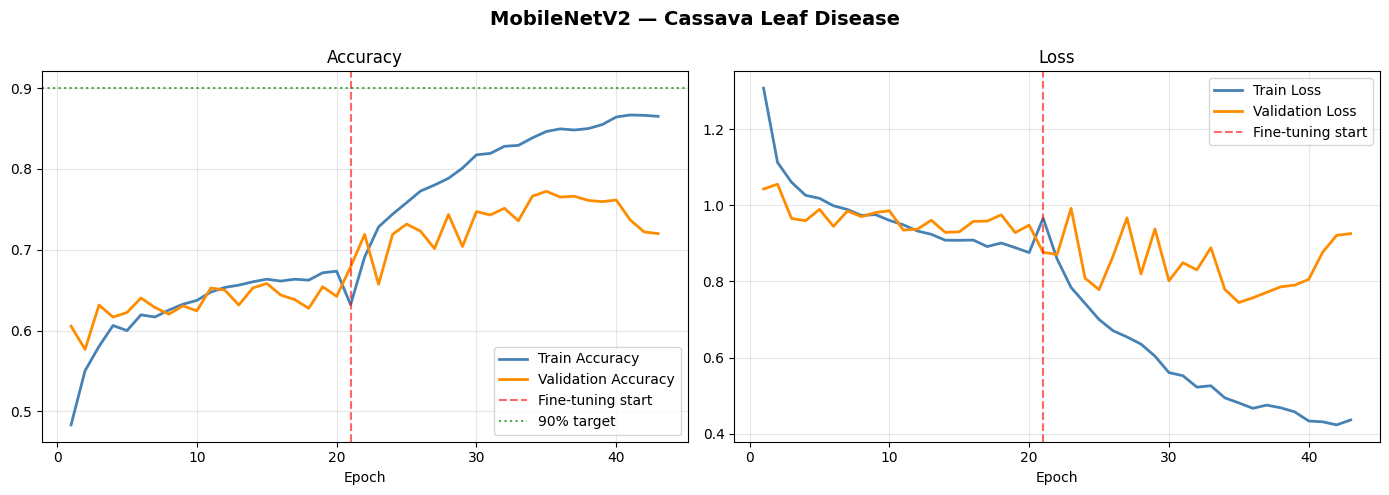


Best Validation Accuracy: 77.24%  (Epoch 35)


In [12]:
acc      = history_p1.history["accuracy"]     + history_p2.history["accuracy"]
val_acc  = history_p1.history["val_accuracy"] + history_p2.history["val_accuracy"]
loss     = history_p1.history["loss"]         + history_p2.history["loss"]
val_loss = history_p1.history["val_loss"]     + history_p2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)
phase2_start = len(history_p1.history["accuracy"]) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 — Cassava Leaf Disease", fontsize=14, fontweight="bold")

ax1.plot(epochs_range, acc,     label="Train Accuracy",      color="steelblue", linewidth=2)
ax1.plot(epochs_range, val_acc, label="Validation Accuracy", color="darkorange", linewidth=2)
ax1.axvline(x=phase2_start, color="red",   linestyle="--", alpha=0.6, label="Fine-tuning start")
ax1.axhline(y=0.90,         color="green", linestyle=":",  alpha=0.7, label="90% target")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss,     label="Train Loss",      color="steelblue", linewidth=2)
ax2.plot(epochs_range, val_loss, label="Validation Loss", color="darkorange", linewidth=2)
ax2.axvline(x=phase2_start, color="red", linestyle="--", alpha=0.6, label="Fine-tuning start")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=150, bbox_inches="tight")
plt.show()

best_val = max(val_acc)
best_ep  = val_acc.index(best_val) + 1
print(f"\nBest Validation Accuracy: {best_val*100:.2f}%  (Epoch {best_ep})")

## 10. Save Final Model

In [13]:
model.save(MODEL_SAVE)
print(f"✓ Model saved: {MODEL_SAVE}")
print(f"✓ Training log: {LOG_CSV}")
print(f"✓ Curves: {PLOT_FILE}")

✓ Model saved: cassava_mobilenetv2_final.h5
✓ Training log: cassava_mobilenetv2_log.csv
✓ Curves: training_history_mobilenet.png
